In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [19]:
df = pd.read_csv('Final_Project_very_Cleaned.csv')

df_model = pd.get_dummies(df, drop_first=True)

print("✅ Data Loaded and Encoded!")
print(f"Total Rows: {df_model.shape[0]}, Total Columns: {df_model.shape[1]}")
df_model.head()

✅ Data Loaded and Encoded!
Total Rows: 68265, Total Columns: 36


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Unknown,Partner_Yes,Dependents_Unknown,Dependents_Yes,...,StreamingMovies_Unknown,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaymentMethod_Unknown
0,0.0,3.0,68.61,205.83,1,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
1,1.0,2.0,23.15,46.30,0,True,False,True,False,False,...,False,False,True,False,True,True,False,False,False,False
2,0.0,42.0,42.63,1790.46,1,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
3,0.0,40.0,75.04,3001.60,0,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,1.0,17.0,22.38,380.46,1,True,False,True,False,True,...,False,False,False,True,True,False,False,True,False,False


In [15]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 54612 rows
Testing set size: 13653 rows


In [16]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

Accuracy Score: 76.96%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.66      0.75      7226
           1       0.70      0.89      0.79      6427

    accuracy                           0.77     13653
   macro avg       0.79      0.78      0.77     13653
weighted avg       0.79      0.77      0.77     13653



/tmp/ipython-input-1578489129.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


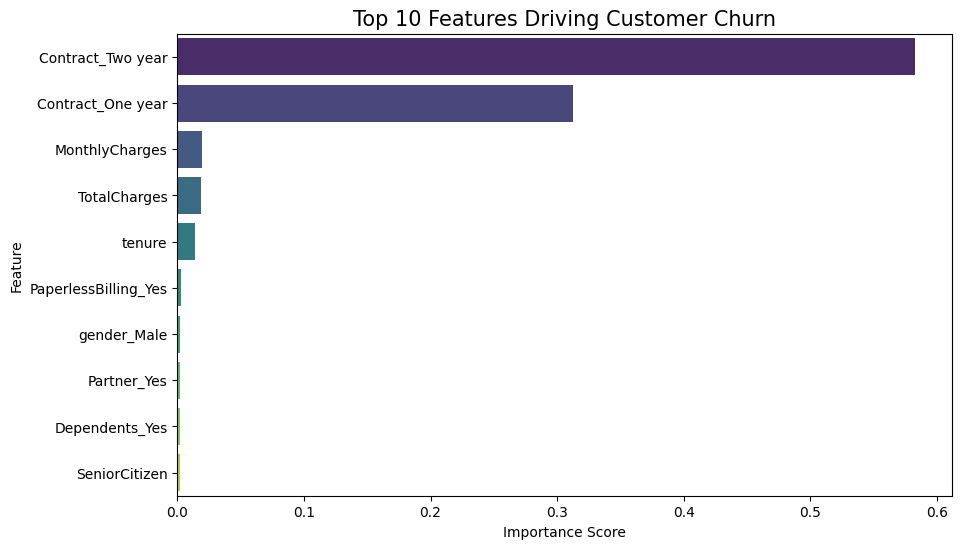

                 Feature  Importance
28     Contract_Two year    0.582933
27     Contract_One year    0.312583
2         MonthlyCharges    0.019173
3           TotalCharges    0.018421
1                 tenure    0.013733
29  PaperlessBilling_Yes    0.002641
4            gender_Male    0.002544
6            Partner_Yes    0.002474
8         Dependents_Yes    0.002299
0          SeniorCitizen    0.002271


In [17]:
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Features Driving Customer Churn', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print(feature_importance_df.head(10))

⏳ Training Logistic Regression Model...

📊 Model Comparison Results:
1️⃣ Random Forest Accuracy:      76.96% (Winner! 🏆)
2️⃣ Logistic Regression Accuracy: 76.95%


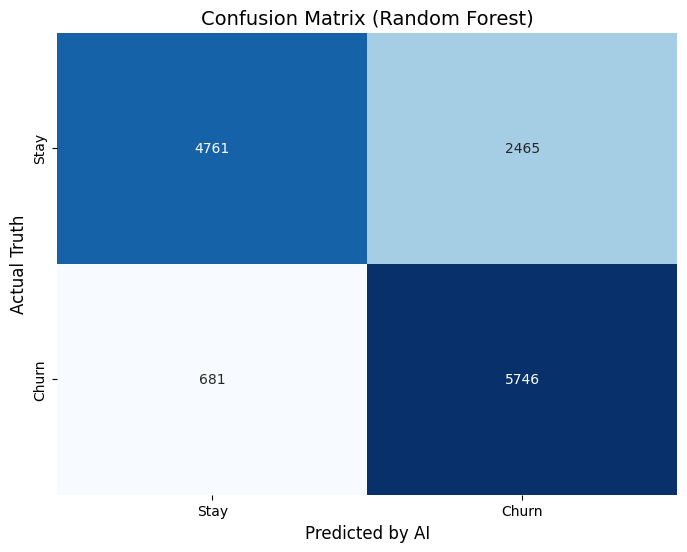

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("⏳ Training Logistic Regression Model...")
log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log) * 100
acc_rf = accuracy_score(y_test, y_pred) * 100

print(f"1️⃣ Random Forest Accuracy:      {acc_rf:.2f}%" )
print(f"2️⃣ Logistic Regression Accuracy: {acc_log:.2f}%")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])

plt.title('Confusion Matrix (Random Forest)', fontsize=14)
plt.xlabel('Predicted by AI', fontsize=12)
plt.ylabel('Actual Truth', fontsize=12)
plt.show()